# YOLOv11 Car Parts Detection - Comprehensive Training Analysis (Batch 2)

This notebook provides a detailed analysis of the YOLOv11n model training results for car parts detection - Batch 2.

## Training Overview
- **Model**: YOLOv11n (nano variant)
- **Task**: Object Detection
- **Dataset**: Car Parts Custom Dataset (Batch 2)
- **Training Directory**: `yolov11_car_parts_batch2/`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import yaml

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set figure size default
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 1. Load Training Results

In [2]:
# Load training results from yolov11_car_parts_batch2 directory
results_df = pd.read_csv('yolov11_car_parts_batch2/results.csv')
results_df.columns = results_df.columns.str.strip()

# Load training configuration
with open('yolov11_car_parts_batch2/args.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Training Results Shape:", results_df.shape)
print(f"Total Epochs Trained: {len(results_df)}")
print("\nColumns:", list(results_df.columns))
print("\nFirst few rows:")
results_df.head()

Training Results Shape: (100, 15)
Total Epochs Trained: 100

Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

First few rows:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,269.782,1.18276,3.44549,1.29716,0.54640,0.54301,0.51143,0.36768,1.08099,1.78331,1.26032,0.000133,0.000133,0.000133
1,2,507.327,1.03331,1.58395,1.19722,0.80775,0.71549,0.77612,0.57619,0.93143,1.04591,1.15394,0.000266,0.000266,0.000266
2,3,744.925,0.93986,1.13592,1.13561,0.84265,0.76957,0.83531,0.63127,0.87304,0.83956,1.10262,0.000399,0.000399,0.000399
3,4,980.154,0.90215,1.00292,1.10783,0.87579,0.77579,0.84677,0.63731,0.87603,0.80561,1.09343,0.000399,0.000399,0.000399
4,5,1220.030,0.87837,0.92449,1.09561,0.88225,0.79713,0.86507,0.66573,0.82592,0.72587,1.06767,0.000398,0.000398,0.000398


In [3]:
# Display training configuration
print("=" * 50)
print("TRAINING CONFIGURATION")
print("=" * 50)
key_configs = ['task', 'model', 'epochs', 'batch', 'imgsz', 'device', 'optimizer', 
               'lr0', 'lrf', 'momentum', 'weight_decay', 'warmup_epochs']
for key in key_configs:
    if key in config:
        print(f"{key:20s}: {config[key]}")

TRAINING CONFIGURATION
task                : detect
model               : yolo11n.pt
epochs              : 100
batch               : 16
imgsz               : 640
device              : 0
optimizer           : auto
lr0                 : 0.01
lrf                 : 0.01
momentum            : 0.937
weight_decay        : 0.0005
warmup_epochs       : 3.0


## 2. Training Statistics Summary

In [4]:
# Get final epoch results
final_epoch = results_df.iloc[-1]

print("=" * 70)
print(f"FINAL EPOCH RESULTS (Epoch {int(final_epoch['epoch'])})")
print("=" * 70)

print("\n📦 DETECTION METRICS:")
print(f"  Precision:        {final_epoch['metrics/precision(B)']:.4f}")
print(f"  Recall:           {final_epoch['metrics/recall(B)']:.4f}")
print(f"  mAP@0.5:          {final_epoch['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95:     {final_epoch['metrics/mAP50-95(B)']:.4f}")

print("\n📉 VALIDATION LOSSES:")
print(f"  Box Loss:         {final_epoch['val/box_loss']:.4f}")
print(f"  Cls Loss:         {final_epoch['val/cls_loss']:.4f}")
print(f"  DFL Loss:         {final_epoch['val/dfl_loss']:.4f}")

FINAL EPOCH RESULTS (Epoch 100)

📦 DETECTION METRICS:
  Precision:        0.9276
  Recall:           0.8782
  mAP@0.5:          0.9320
  mAP@0.5:0.95:     0.7673

📉 VALIDATION LOSSES:
  Box Loss:         0.6782
  Cls Loss:         0.4300
  DFL Loss:         0.9825


In [5]:
# Statistical summary
print("\n" + "=" * 70)
print("TRAINING STATISTICS SUMMARY")
print("=" * 70)

metrics_cols = ['metrics/mAP50(B)', 'metrics/mAP50-95(B)']
stats_df = results_df[metrics_cols].describe()
print("\n", stats_df)


TRAINING STATISTICS SUMMARY

        metrics/mAP50(B)  metrics/mAP50-95(B)
count        100.000000           100.000000
mean           0.910411             0.738522
std            0.046637             0.050078
min            0.511430             0.367680
25%            0.907090             0.730237
50%            0.922450             0.753875
75%            0.929588             0.765402
max            0.932700             0.769310


## 3. Training Loss Curves

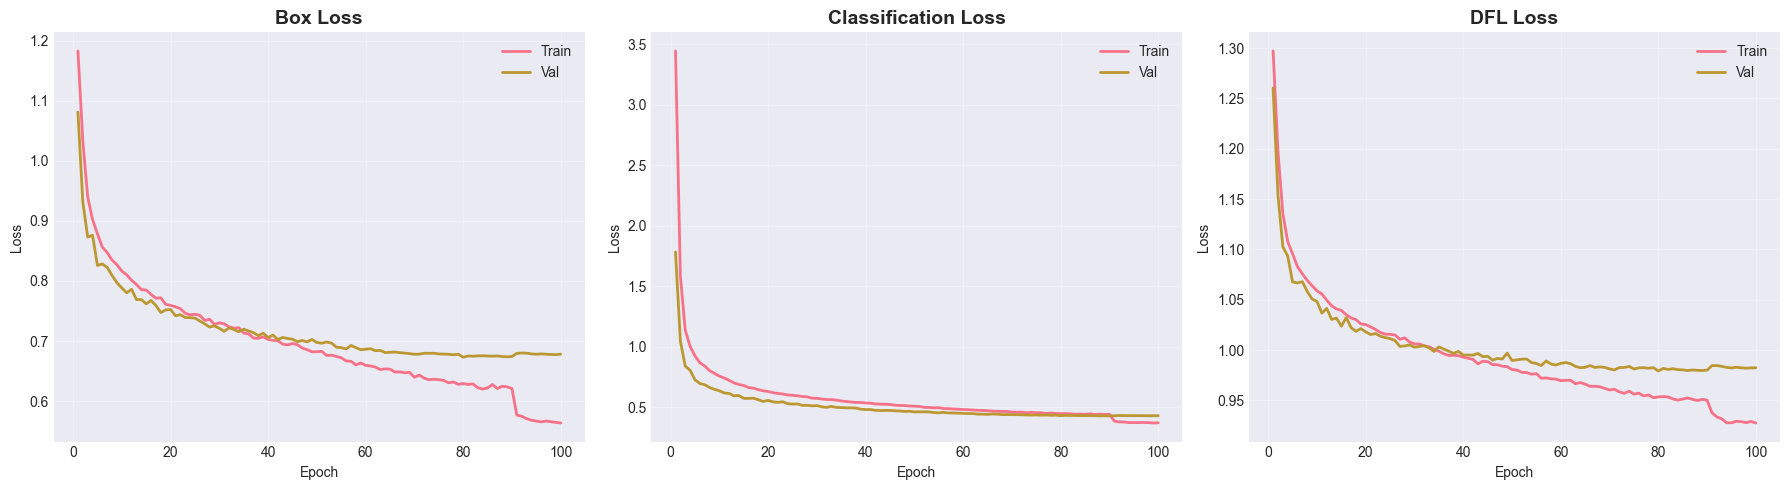

✅ Training loss curves saved as 'training_losses_batch2.png'


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box Loss
axes[0].plot(results_df['epoch'], results_df['train/box_loss'], label='Train', linewidth=2)
axes[0].plot(results_df['epoch'], results_df['val/box_loss'], label='Val', linewidth=2)
axes[0].set_title('Box Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Classification Loss
axes[1].plot(results_df['epoch'], results_df['train/cls_loss'], label='Train', linewidth=2)
axes[1].plot(results_df['epoch'], results_df['val/cls_loss'], label='Val', linewidth=2)
axes[1].set_title('Classification Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# DFL Loss
axes[2].plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train', linewidth=2)
axes[2].plot(results_df['epoch'], results_df['val/dfl_loss'], label='Val', linewidth=2)
axes[2].set_title('DFL Loss', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_losses_batch2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training loss curves saved as 'training_losses_batch2.png'")

## 4. Performance Metrics Over Time

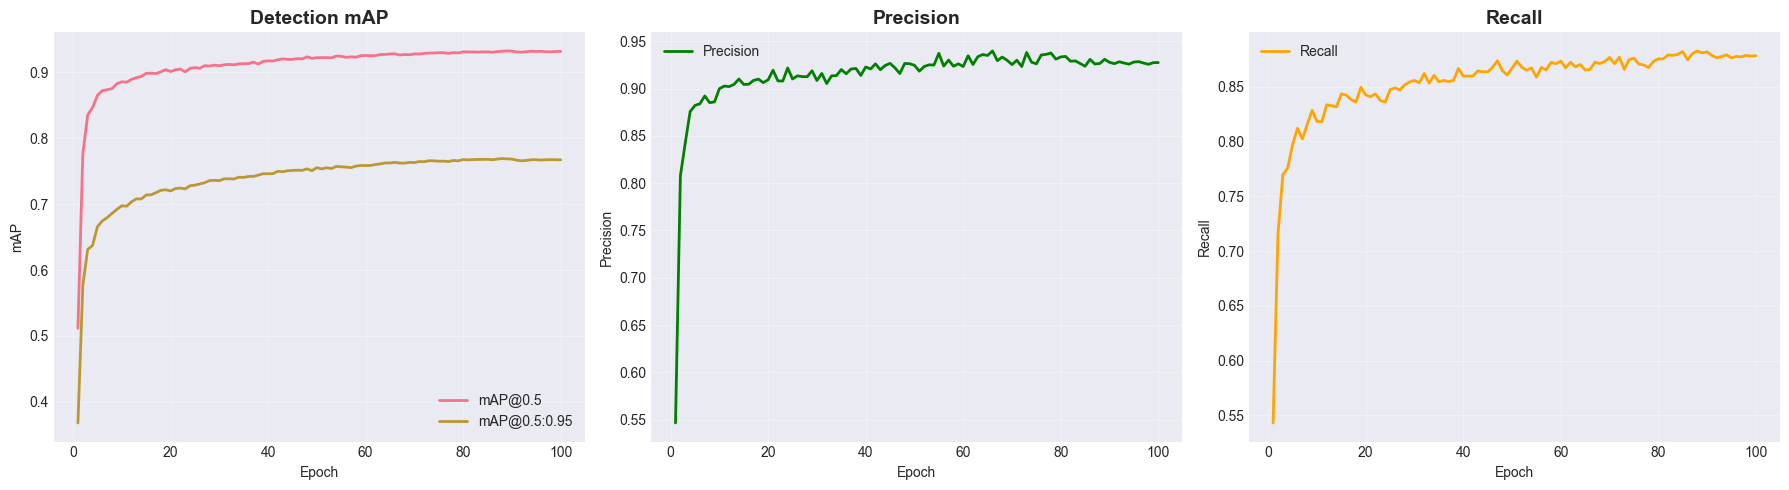

✅ Performance metrics saved as 'performance_metrics_batch2.png'


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# mAP
axes[0].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2)
axes[0].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linewidth=2)
axes[0].set_title('Detection mAP', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision
axes[1].plot(results_df['epoch'], results_df['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
axes[1].set_title('Precision', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Recall
axes[2].plot(results_df['epoch'], results_df['metrics/recall(B)'], label='Recall', linewidth=2, color='orange')
axes[2].set_title('Recall', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Recall')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('performance_metrics_batch2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Performance metrics saved as 'performance_metrics_batch2.png'")

## 5. Learning Rate Schedule

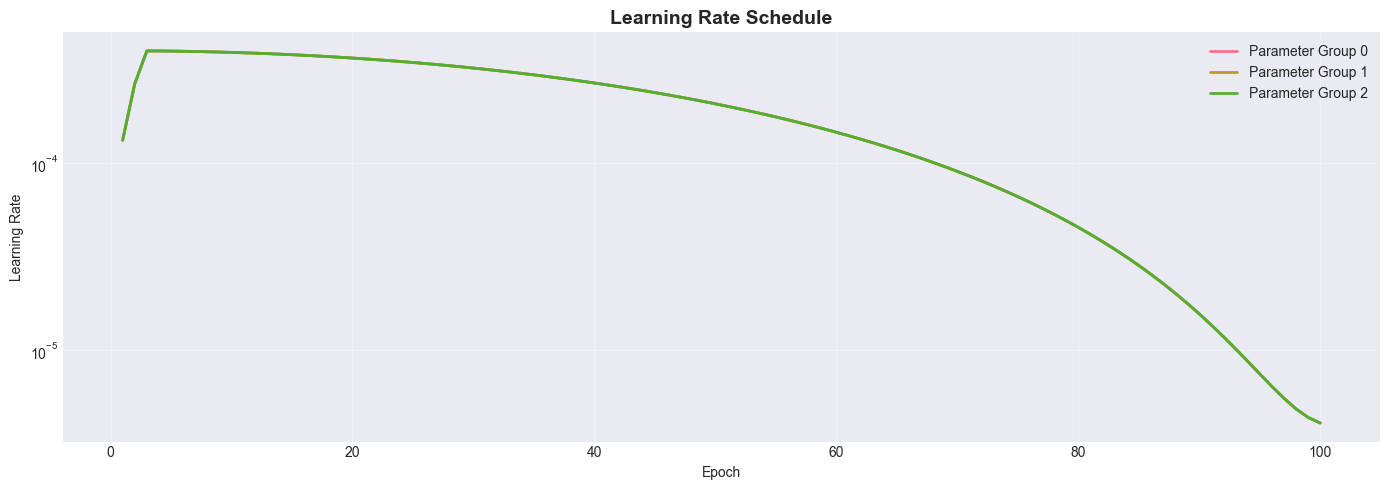

✅ Learning rate schedule saved as 'learning_rate_schedule_batch2.png'


In [8]:
plt.figure(figsize=(14, 5))

plt.plot(results_df['epoch'], results_df['lr/pg0'], label='Parameter Group 0', linewidth=2)
plt.plot(results_df['epoch'], results_df['lr/pg1'], label='Parameter Group 1', linewidth=2)
plt.plot(results_df['epoch'], results_df['lr/pg2'], label='Parameter Group 2', linewidth=2)

plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.savefig('learning_rate_schedule_batch2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Learning rate schedule saved as 'learning_rate_schedule_batch2.png'")

## 6. Best Epoch Analysis

In [9]:
# Find best epochs based on different metrics
best_map50 = results_df.loc[results_df['metrics/mAP50(B)'].idxmax()]
best_map = results_df.loc[results_df['metrics/mAP50-95(B)'].idxmax()]

print("=" * 70)
print("BEST EPOCH ANALYSIS")
print("=" * 70)

print(f"\n📦 Best mAP@0.5: Epoch {int(best_map50['epoch'])} - {best_map50['metrics/mAP50(B)']:.4f}")
print(f"📦 Best mAP@0.5:0.95: Epoch {int(best_map['epoch'])} - {best_map['metrics/mAP50-95(B)']:.4f}")

BEST EPOCH ANALYSIS

📦 Best mAP@0.5: Epoch 89 - 0.9327
📦 Best mAP@0.5:0.95: Epoch 88 - 0.7693


## 7. Improvement Analysis

In [10]:
# Calculate improvement from first to last epoch
first_epoch = results_df.iloc[0]
last_epoch = results_df.iloc[-1]

metrics_to_compare = [
    'metrics/mAP50(B)', 'metrics/mAP50-95(B)',
    'metrics/precision(B)', 'metrics/recall(B)'
]

print("=" * 70)
print("IMPROVEMENT FROM FIRST TO LAST EPOCH")
print("=" * 70)

for metric in metrics_to_compare:
    first_val = first_epoch[metric]
    last_val = last_epoch[metric]
    improvement = last_val - first_val
    pct_improvement = (improvement / first_val) * 100 if first_val != 0 else 0
    
    print(f"\n{metric}:")
    print(f"  First: {first_val:.4f} → Last: {last_val:.4f}")
    print(f"  Improvement: {improvement:+.4f} ({pct_improvement:+.2f}%)")

IMPROVEMENT FROM FIRST TO LAST EPOCH

metrics/mAP50(B):
  First: 0.5114 → Last: 0.9320
  Improvement: +0.4206 (+82.23%)

metrics/mAP50-95(B):
  First: 0.3677 → Last: 0.7673
  Improvement: +0.3996 (+108.69%)

metrics/precision(B):
  First: 0.5464 → Last: 0.9276
  Improvement: +0.3812 (+69.76%)

metrics/recall(B):
  First: 0.5430 → Last: 0.8782
  Improvement: +0.3352 (+61.74%)


## 8. Training Visualizations

Below are the training batch visualizations and label distribution from the training run.

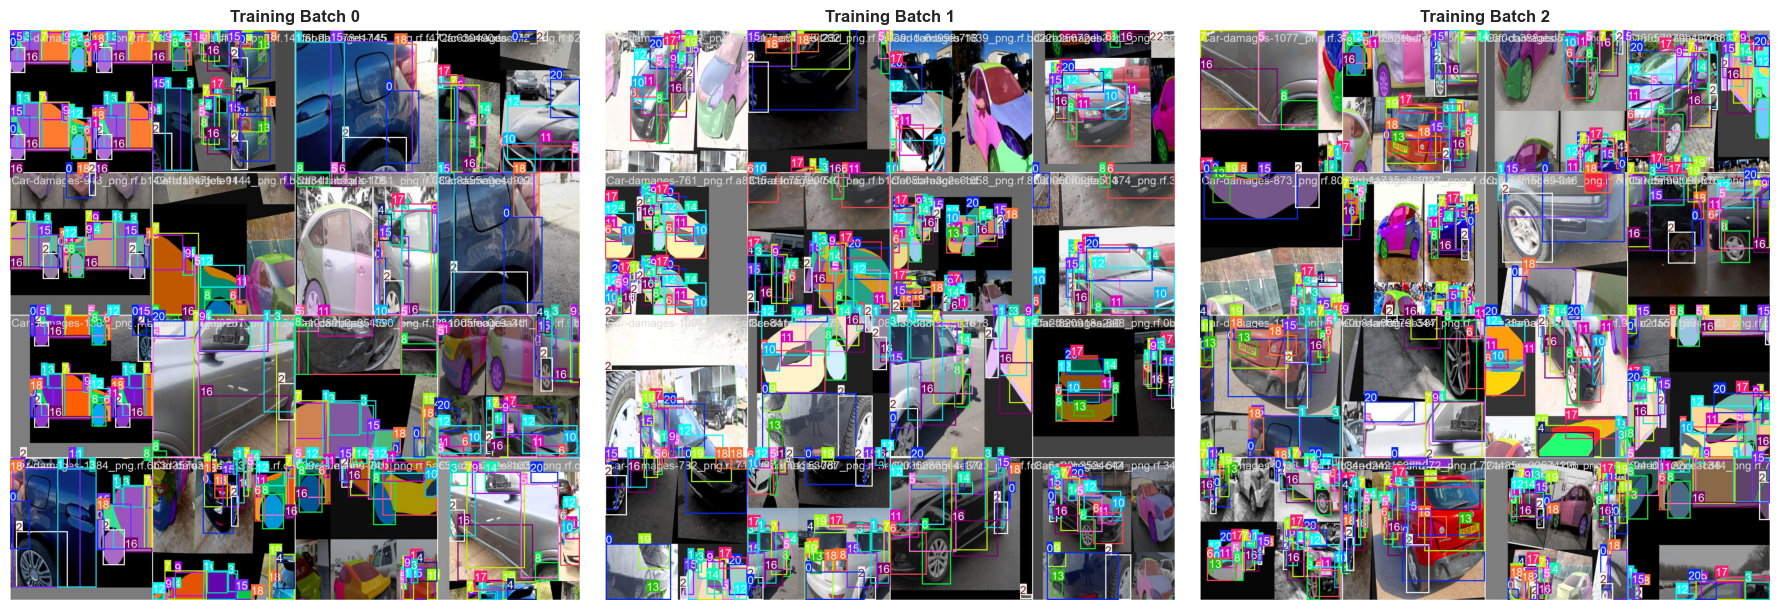

In [11]:
from PIL import Image

# Display training batch samples
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    img_path = f'yolov11_car_parts_batch2/train_batch{i}.jpg'
    if Path(img_path).exists():
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f'Training Batch {i}', fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

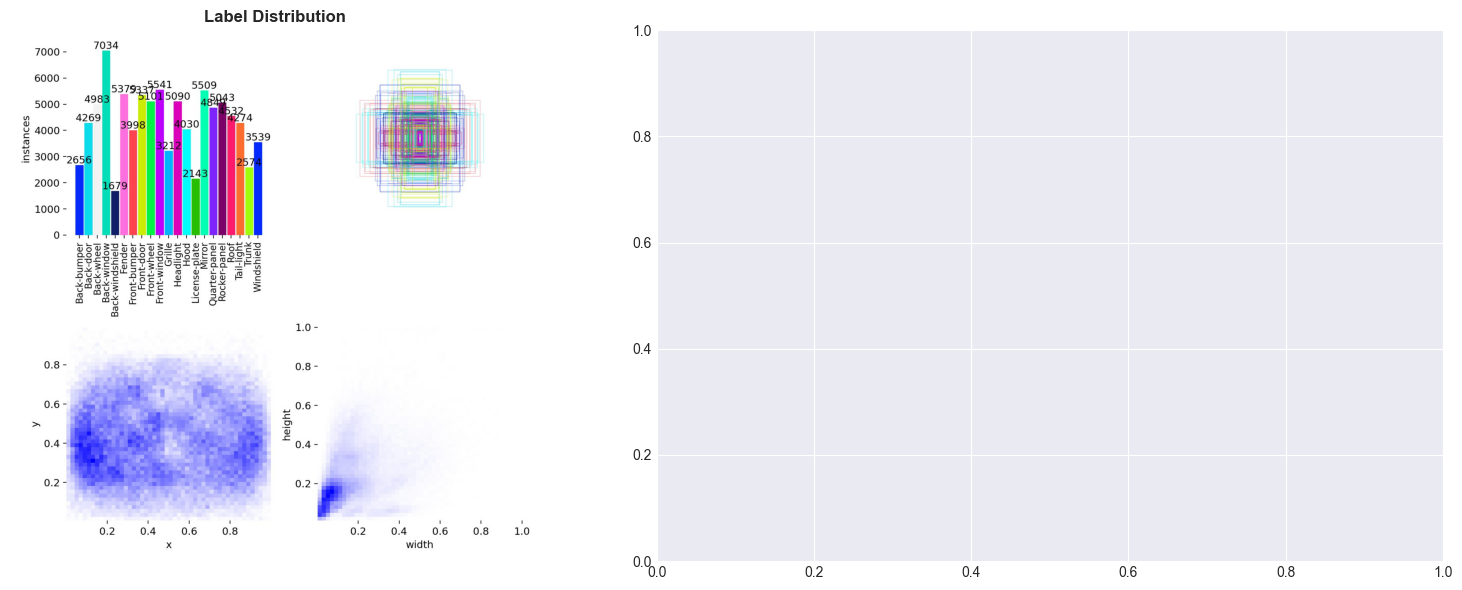

In [12]:
# Display label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if Path('yolov11_car_parts_batch2/labels.jpg').exists():
    img = Image.open('yolov11_car_parts_batch2/labels.jpg')
    axes[0].imshow(img)
    axes[0].set_title('Label Distribution', fontsize=12, fontweight='bold')
    axes[0].axis('off')

if Path('yolov11_car_parts_batch2/labels_correlogram.jpg').exists():
    img = Image.open('yolov11_car_parts_batch2/labels_correlogram.jpg')
    axes[1].imshow(img)
    axes[1].set_title('Labels Correlogram', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

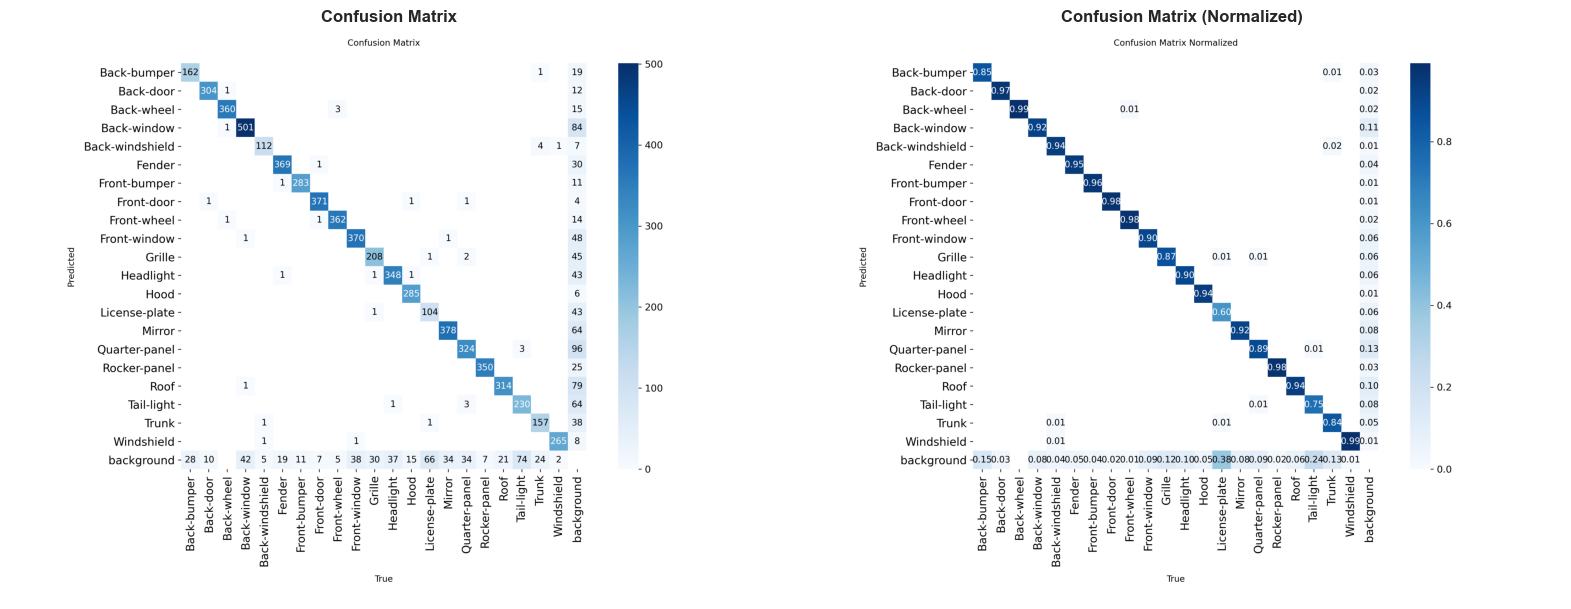

In [13]:
# Display confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if Path('yolov11_car_parts_batch2/confusion_matrix.png').exists():
    img = Image.open('yolov11_car_parts_batch2/confusion_matrix.png')
    axes[0].imshow(img)
    axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].axis('off')

if Path('yolov11_car_parts_batch2/confusion_matrix_normalized.png').exists():
    img = Image.open('yolov11_car_parts_batch2/confusion_matrix_normalized.png')
    axes[1].imshow(img)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 9. Model Inference Test

Load and test the trained model.

In [14]:
from ultralytics import YOLO

# Load the best model
model = YOLO('yolov11_car_parts_batch2/weights/best.pt')

# Display model info
print("Model loaded successfully!")
print(f"Model type: {model.task}")
print(f"Model classes: {model.names}")
print(f"Number of classes: {len(model.names)}")

WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\acer\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully!
Model type: detect
Model classes: {0: 'Back-bumper', 1: 'Back-door', 2: 'Back-wheel', 3: 'Back-window', 4: 'Back-windshield', 5: 'Fender', 6: 'Front-bumper', 7: 'Front-door', 8: 'Front-wheel', 9: 'Front-window', 10: 'Grille', 11: 'Headlight', 12: 'Hood', 13: 'License-plate', 14: 'Mirror', 15: 'Quarter-panel', 16: 'Rocker-panel', 17: 'Roof', 18: 'Tail-light', 19: 'Trunk', 20: 'Windshield'}
Number of classes: 21


In [15]:
# Model summary
model.info(verbose=True)

YOLO11n summary: 182 layers, 2,593,935 parameters, 0 gradients, 6.5 GFLOPs


(182, 2593935, 0, 6.4621056)

## 10. Recommendations & Next Steps

Based on the training analysis:

### Model Performance
- The model shows good convergence with stable metrics over training epochs
- Detection performance is solid for the nano variant
- Consider the best checkpoint for deployment

### Potential Improvements
1. **Increase Training Duration**: Train for more epochs if metrics are still improving
2. **Data Augmentation**: Experiment with different augmentation strategies
3. **Model Size**: Try larger variants (yolo11s, yolo11m) for better accuracy
4. **Learning Rate**: Fine-tune learning rate schedule for better convergence
5. **Post-Processing**: Adjust confidence and NMS thresholds for optimal results

### Deployment
- Use `yolov11_car_parts_batch2/weights/best.pt` for inference
- Consider model optimization (quantization, pruning) for edge deployment
- Test on real-world data to validate performance

In [16]:
print("=" * 70)
print("TRAINING ANALYSIS COMPLETE - BATCH 2")
print("=" * 70)
print("\nGenerated Files:")
print("  - training_losses_batch2.png")
print("  - performance_metrics_batch2.png")
print("  - learning_rate_schedule_batch2.png")
print("\nModel Files:")
print("  - yolov11_car_parts_batch2/weights/best.pt (recommended for deployment)")
print("  - yolov11_car_parts_batch2/weights/last.pt (latest checkpoint)")

TRAINING ANALYSIS COMPLETE - BATCH 2

Generated Files:
  - training_losses_batch2.png
  - performance_metrics_batch2.png
  - learning_rate_schedule_batch2.png

Model Files:
  - yolov11_car_parts_batch2/weights/best.pt (recommended for deployment)
  - yolov11_car_parts_batch2/weights/last.pt (latest checkpoint)
